In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import graphviz 
from torchview import draw_graph

from src.Elements import Elements

import torch
import torch.nn as nn
import torch.nn.functional as F


In [ ]:

class XRFAutoencoder(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
         
# Encoder
        self.encoder = nn.Sequential(
            nn.LazyConv1d(16, kernel_size=3, padding=1),
            nn.AvgPool1d(2),
            nn.ReLU(),
            nn.LazyConv1d(32, kernel_size=3, padding=1),
            nn.AvgPool1d(2),
            nn.ReLU(),
            nn.LazyConv1d(64, kernel_size=3, padding=1),
            nn.AvgPool1d(2),
            nn.ReLU(),
            nn.LazyConv1d(128, kernel_size=3, padding=1),
            nn.AvgPool1d(2),
            nn.ReLU(),
            nn.LazyConv1d(256, kernel_size=3, padding=1),
            nn.AvgPool1d(2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.LazyLinear(latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.LazyLinear(256),
            nn.Unflatten(-1, (1, -1)),
            nn.LazyConv1d(256, 1),
            nn.ReLU(),
            nn.LazyConv1d(256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.LazyConv1d(128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.LazyConv1d(64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.LazyConv1d(16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.LazyConv1d(1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
        

    def forward(self, x):

        z = self.encoder(x)

        y = F.sigmoid(z)

        minus_infinity_mask = (y < 0.5).bool()
        z = F.softmax(z.masked_fill(minus_infinity_mask, -1e9), dim=1)
        
        x_prime = self.decoder(z)
        return x_prime, y, z
    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = XRFAutoencoder(latent_dim=len(Elements.LINES)).to(device)
# print()
print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
# a = 1
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

graph = draw_graph(model, input_size=(64, 1, 4096))
graphviz.set_jupyter_format('png')


torch.Size([64, 1, 4096])
458536


'png'

In [ ]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/artificial/X.npy")
y = np.load("data/artificial/y.npy")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 64)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 64)


In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
mse_criterion = nn.MSELoss()
bce_criterion = nn.BCELoss()
def custom_criterion(y_pred, x_pred , y_batch, X_batch, alpha=0.5):
    x_loss = mse_criterion(x_pred, X_batch)
    y_batch[y_batch > 0] = 1
    y_loss = bce_criterion(y_pred, y_batch)
    return alpha * y_loss + (1 - alpha) * x_loss, x_loss, y_loss

train_history, valid_history, best_loss, best_weights = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=custom_criterion, epochs=50, mode="constrained_autoencoder")

2025-02-14 14:51:22,774 - Epoch 1/50 started.
2025-02-14 14:51:24,499 - Batch 100, Loss: 0.3171
2025-02-14 14:51:26,117 - Batch 200, Loss: 0.3316
2025-02-14 14:51:27,756 - Batch 300, Loss: 0.3103
2025-02-14 14:51:29,373 - Batch 400, Loss: 0.3138
2025-02-14 14:51:31,014 - Batch 500, Loss: 0.3149
2025-02-14 14:51:32,639 - Batch 600, Loss: 0.3230
2025-02-14 14:51:34,244 - Batch 700, Loss: 0.3095
2025-02-14 14:51:34,324 - Train Epoch Average Loss: 0.3210
2025-02-14 14:51:34,752 - Validation Loss: 0.3111
2025-02-14 14:51:34,757 - New best model saved.
2025-02-14 14:51:34,758 - Epoch 1 finished in 11.98 seconds.

2025-02-14 14:51:34,758 - Epoch 2/50 started.
2025-02-14 14:51:36,385 - Batch 100, Loss: 0.3086
2025-02-14 14:51:37,989 - Batch 200, Loss: 0.3143
2025-02-14 14:51:39,595 - Batch 300, Loss: 0.3141
2025-02-14 14:51:41,215 - Batch 400, Loss: 0.3198
2025-02-14 14:51:42,847 - Batch 500, Loss: 0.3026
2025-02-14 14:51:44,432 - Batch 600, Loss: 0.3105
2025-02-14 14:51:46,037 - Batch 700, Lo

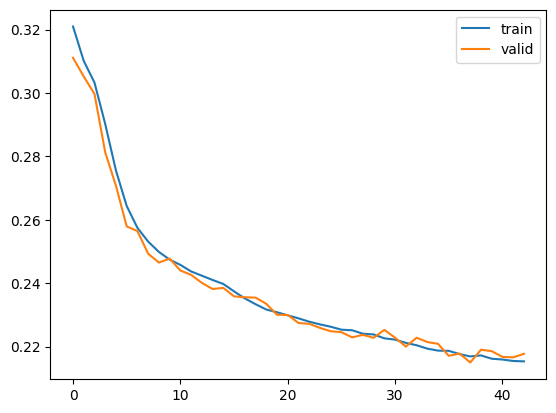

In [8]:
import matplotlib.pyplot as plt
plt.plot(train_history, label="train")
plt.plot(valid_history, label="valid")
plt.legend()


In [15]:
import matplotlib.pyplot as plt

for i, (X_batch, y_batch) in enumerate(trainloader):
    X_true, y_true = X_batch.cpu().squeeze().detach().numpy()[0], y_batch.cpu().squeeze().detach().numpy()[0]
    X_pred, y_pred = model(X_batch)[0].cpu().squeeze().detach().numpy()[0], model(X_batch)[1].cpu().squeeze().detach().numpy()[0]

    plt.figure(i)
    plt.plot(X_true, label=f"input{i}")
    plt.plot(X_pred, label=f"output{i}")
    plt.legend()
    if i == 10:
        break

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 15.99 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 45.81 GiB is allocated by PyTorch, and 504.74 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [10]:
from pathlib import Path
import numpy as np
npz = np.load(Path("data/Sobieski/Sobieski_data_corr_total.npz"), allow_pickle=True)
sobieski_e_xy = npz["E_xy"]

In [11]:
from skimage.filters import gaussian
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from scipy.ndimage import convolve
import matplotlib.pyplot as plt 
from skimage.measure import block_reduce


peaks_sobieski = [817, 1016,1347, 1598]
energies_sobieski =[6.405, 8.046, 10.551, 12.614] 

kernel_size = 3

sobieski_averaged = block_reduce(sobieski_e_xy, block_size=(kernel_size, kernel_size, 1), func=np.mean)

print(sobieski_averaged.shape)

energy_range, spectra = DataPreprocessor.processed_spectra(sobieski_averaged, peaks_sobieski, energies_sobieski)
print(spectra.shape)

(175, 116, 4094)
(175, 116, 4096)


In [12]:
H, W, C = spectra.shape
batch_size_total = H * W
input_tensor = torch.tensor(spectra, dtype=torch.float).view(batch_size_total, C).to(device).unsqueeze(1)

batch_size = 128

outputs = []
for i in range(0, batch_size_total, batch_size):
    batch = input_tensor[i:i + batch_size]
    output = model(batch)
    outputs.append(output)

# final_output = torch.cat(outputs, dim=0).reshape((H, W, C))

# print("Output shape:", final_output.shape) 

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 15.99 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 45.76 GiB is allocated by PyTorch, and 508.74 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
X = torch.cat([outputs[i][0].squeeze(1) for i in range(len(outputs))]).reshape((*spectra.shape[:-1], -1))
Y = torch.cat([outputs[i][1].squeeze(1) for i in range(len(outputs))]).reshape((*spectra.shape[:-1], -1))
Z = torch.cat([outputs[i][2].squeeze(1) for i in range(len(outputs))]).reshape((*spectra.shape[:-1], -1))

In [ ]:
print(X.shape)
print(Y.shape)
print(Z.shape)

torch.Size([105, 70, 4096])
torch.Size([105, 70, 7])
torch.Size([105, 70, 7])


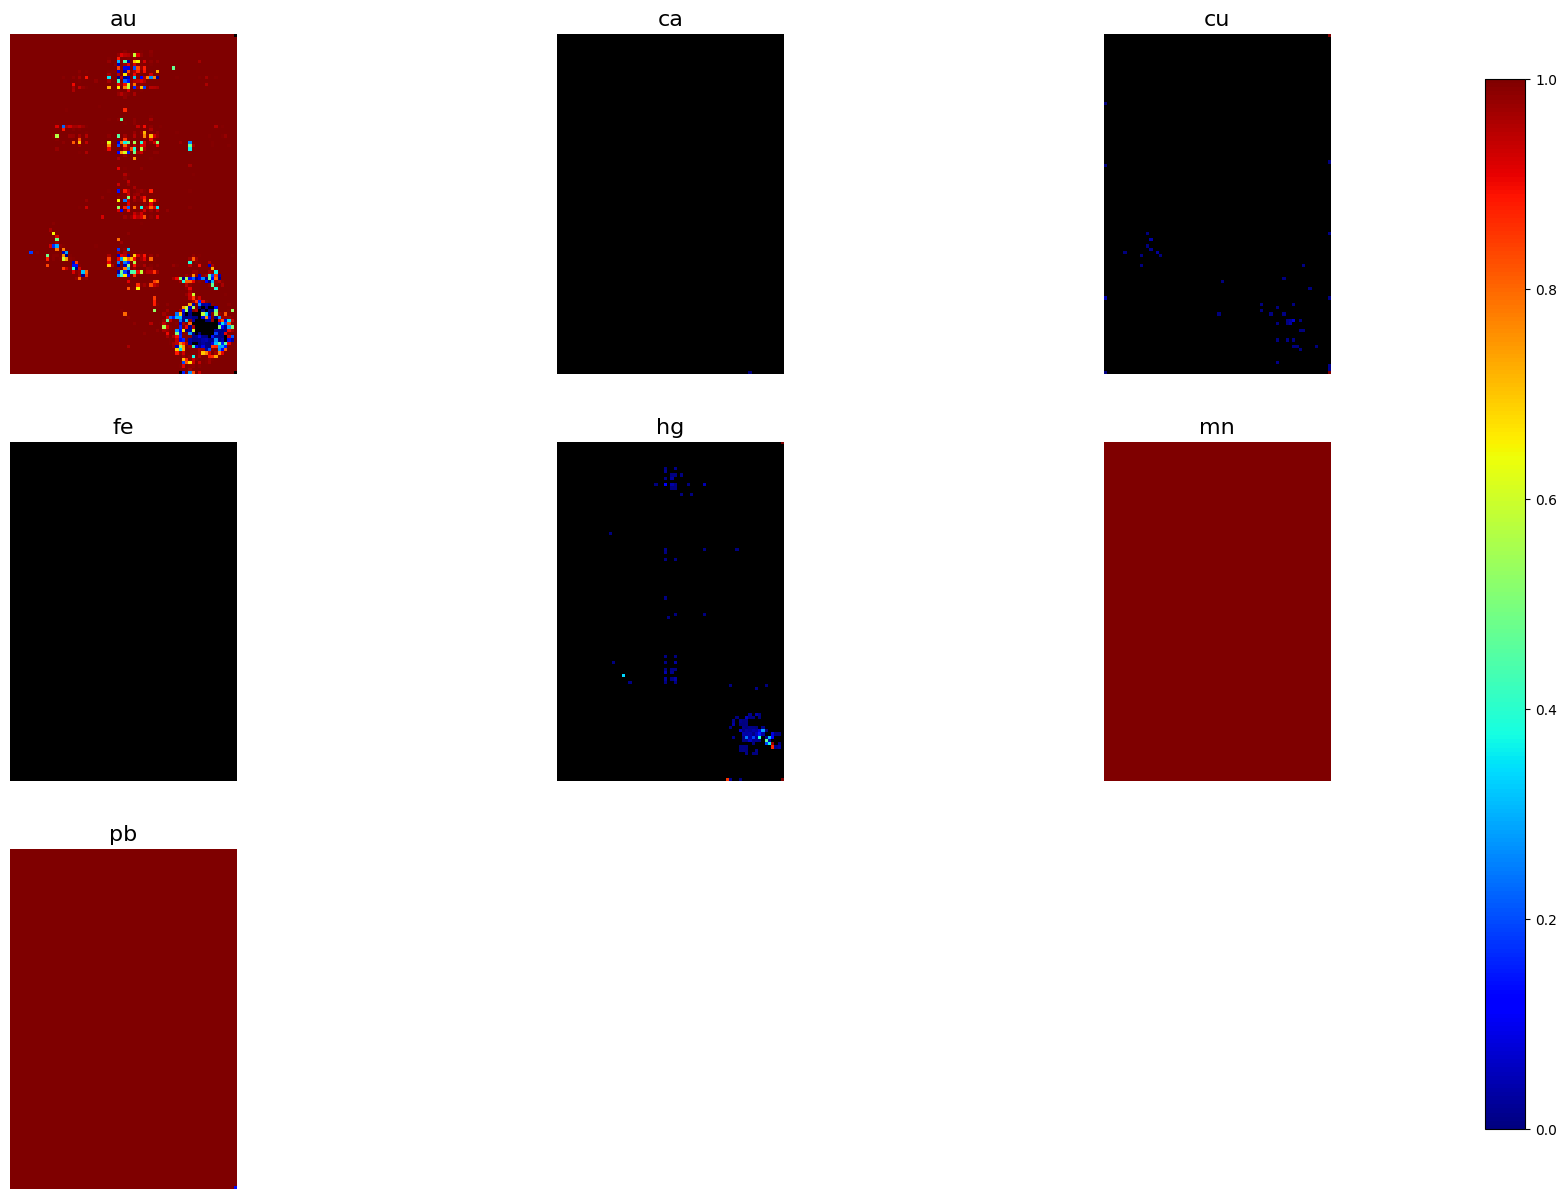

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

tensor = Y.cpu().detach()
# Define the colormap and set values < 1e-3 to black
cmap = plt.cm.jet

# Set values < 1e-3 to black
tensor_np = tensor.numpy()
mask = tensor_np < 1e-3
tensor_np_rgba = cmap(tensor_np)  # Get RGBA values
tensor_np_rgba[mask] = [0, 0, 0, 1]  # Assign black to masked regions

# Plot the images stacked 3 next to each other
fig, axes = plt.subplots(3, 3, figsize=(20, 15))  # Arrange in 3 rows and 3 columns
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Add colorbar axis

for i in range(7):
    row, col = divmod(i, 3)
    im = axes[row, col].imshow(tensor_np_rgba[:, :, i])  # Already RGBA
    axes[row, col].axis("off")
    axes[row, col].set_title(f"{Elements.NUM2SYMBOL[i]}", fontsize=16)  # Increase title font size

# Hide unused subplots
for i in range(7, 9):
    row, col = divmod(i, 3)
    axes[row, col].axis("off")

fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=cbar_ax)  # Add colorbar
plt.show()


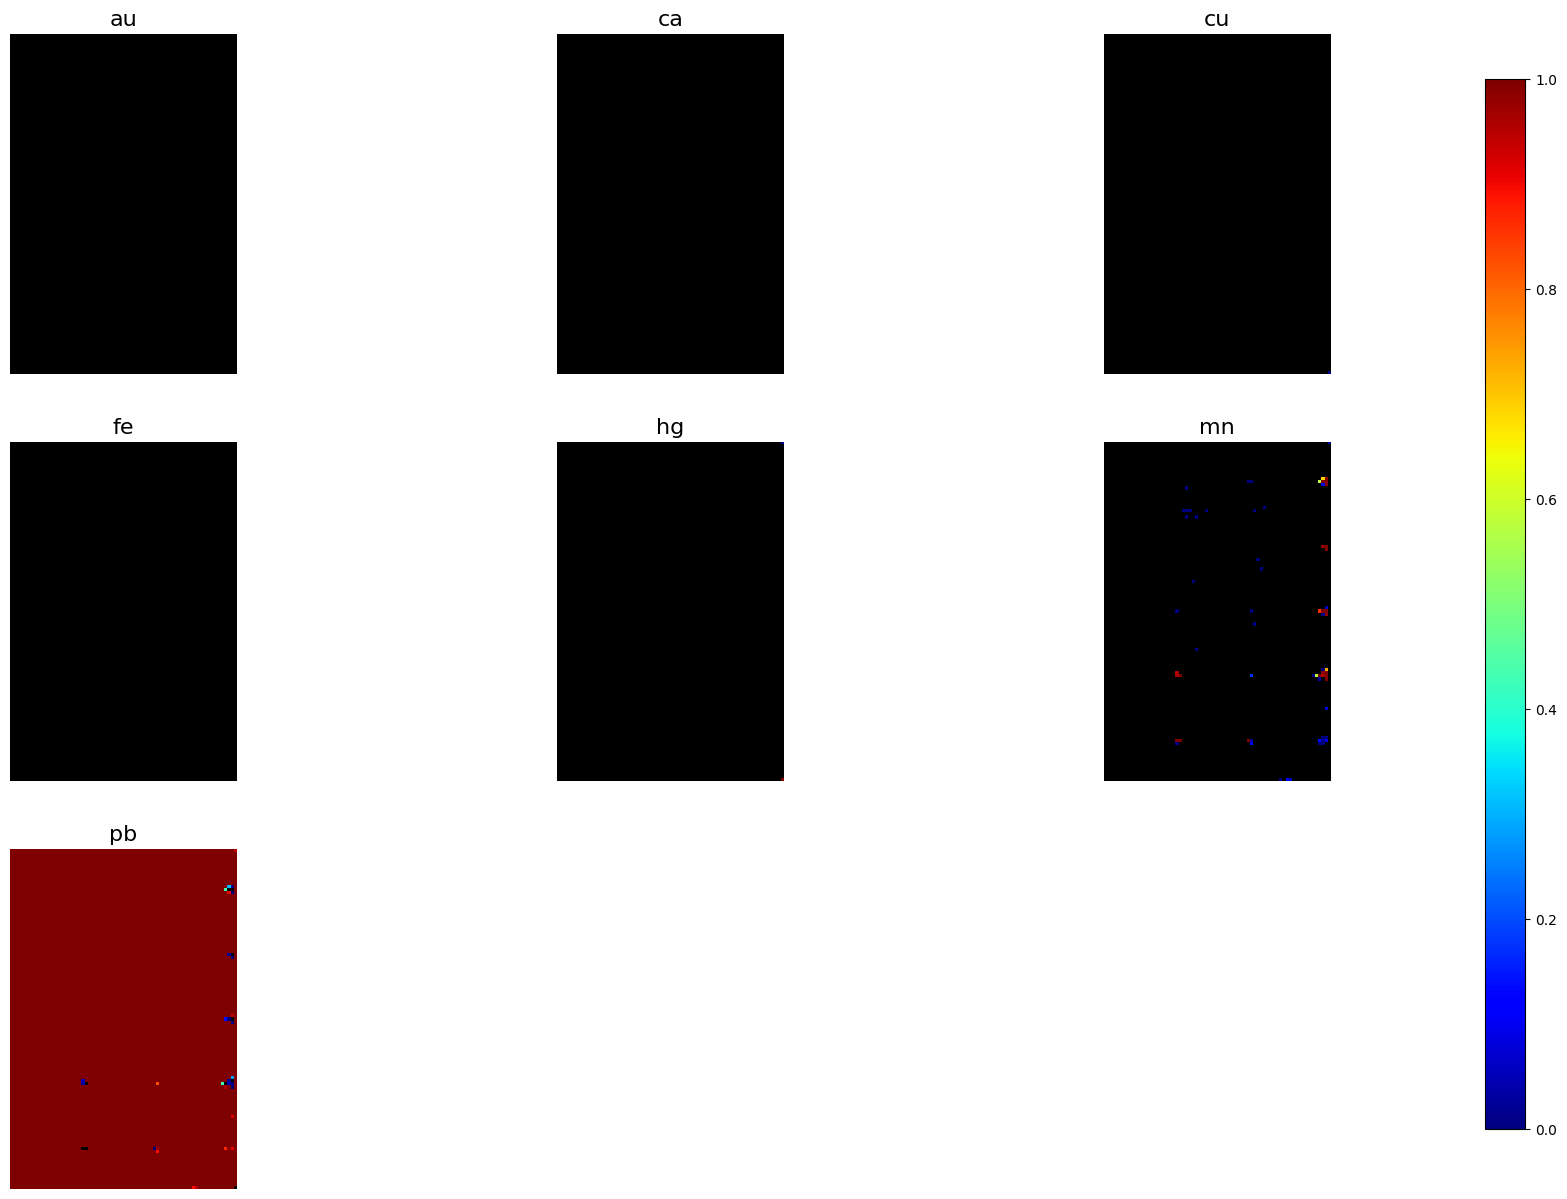

In [ ]:
tensor = Z.cpu().detach()
# Define the colormap and set values < 1e-3 to black
cmap = plt.cm.jet

# Set values < 1e-3 to black
tensor_np = tensor.numpy()
mask = tensor_np < 1e-3
tensor_np_rgba = cmap(tensor_np)  # Get RGBA values
tensor_np_rgba[mask] = [0, 0, 0, 1]  # Assign black to masked regions

# Plot the images stacked 3 next to each other
fig, axes = plt.subplots(3, 3, figsize=(20, 15))  # Arrange in 3 rows and 3 columns
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Add colorbar axis

for i in range(7):
    row, col = divmod(i, 3)
    im = axes[row, col].imshow(tensor_np_rgba[:, :, i])  # Already RGBA
    axes[row, col].axis("off")
    axes[row, col].set_title(f"{Elements.NUM2SYMBOL[i]}", fontsize=16)  # Increase title font size

# Hide unused subplots
for i in range(7, 9):
    row, col = divmod(i, 3)
    axes[row, col].axis("off")

fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=cbar_ax)  # Add colorbar
plt.show()

In [ ]:
print(Z)

tensor([[[1.0000e+00, 2.5284e-09, 1.0333e-08,  ..., 1.9693e-17,
          1.0000e+00, 1.0000e+00],
         [1.0000e+00, 1.8327e-10, 1.1303e-07,  ..., 2.6485e-16,
          1.0000e+00, 1.0000e+00],
         [1.0000e+00, 5.7949e-10, 8.1526e-07,  ..., 1.4143e-13,
          1.0000e+00, 1.0000e+00],
         ...,
         [1.0000e+00, 3.2577e-12, 4.2901e-06,  ..., 9.2231e-14,
          1.0000e+00, 1.0000e+00],
         [1.0000e+00, 1.3287e-11, 4.9426e-06,  ..., 9.6578e-14,
          1.0000e+00, 1.0000e+00],
         [3.0589e-10, 2.2909e-12, 9.9988e-01,  ..., 1.0000e+00,
          1.0000e+00, 1.0000e+00]],

        [[1.0000e+00, 7.5422e-11, 8.3623e-07,  ..., 3.3175e-19,
          1.0000e+00, 1.0000e+00],
         [1.0000e+00, 1.0026e-06, 2.7015e-07,  ..., 1.3295e-13,
          1.0000e+00, 1.0000e+00],
         [1.0000e+00, 8.1949e-08, 9.2239e-08,  ..., 5.1145e-14,
          1.0000e+00, 1.0000e+00],
         ...,
         [1.0000e+00, 2.1211e-08, 7.9631e-09,  ..., 9.3199e-14,
          1.000